In [69]:
import pandas as pd
df = pd.read_csv("Laptops_data_from_flipcart.csv")
df.head()

,Brand_name,Device_name,Operating system,Ram(in GB),Storage(in GB),Price(in ₹),Discount(in percentages),Rating,Warrenty,Processor
0,Samsung,Samsung Galaxy Book4 Metal Intel Core i5 13th ...,Windows 11 Home,8.0,512.0,"₹52,500",32% off,4.4,1 Year Manufacturer Warranty for Laptop and 6 ...,Intel Core i5 Processor (13th Gen)
1,CHUWI,CHUWI Intel Core i3 10th Gen 10100Y,Windows 11 Home,8.0,256.0,"₹19,990",50% off,4.1,1 Year Onsite Warranty,Intel Core i3 Processor (10th Gen)
2,Acer,Acer Aspire 3 (2025) Intel Core i5 13th Gen 1334U,Windows 11 Home,16.0,512.0,"₹41,800",50% off,4.2,3 Years Warranty,Intel Core i5 Processor (13th Gen)
3,Acer,Acer Aspire 3 Intel Celeron Dual Core,Windows 11 Home,8.0,128.0,"₹15,990",51% off,3.8,1 Year Warranty,NaN
4,Acer,Acer Aspire 3 Intel Core i3 12th Gen 1215U,Windows 11 Home,8.0,512.0,"₹27,990",34% off,4.2,1 Year Domestic Warranty,Intel Core i3 Processor (12th Gen)


In [70]:
print("Number of rows (observations):", df.shape[0])
print("Number of columns (features):", df.shape[1])


Number of rows (observations): 960
Number of columns (features): 10


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Brand_name                954 non-null    object 
 1   Device_name               939 non-null    object 
 2   Operating system          907 non-null    object 
 3   Ram(in GB)                934 non-null    float64
 4   Storage(in GB)            822 non-null    float64
 5   Price(in ₹)               960 non-null    object 
 6   Discount(in percentages)  933 non-null    object 
 7   Rating                    930 non-null    float64
 8   Warrenty                  841 non-null    object 
 9   Processor                 649 non-null    object 
dtypes: float64(3), object(7)
memory usage: 75.1+ KB


In [72]:
print("Total missing values:", df.isnull().sum().sum())


Total missing values: 731


In [73]:
df.isnull().sum()

Brand_name                    6
Device_name                  21
Operating system             53
Ram(in GB)                   26
Storage(in GB)              138
Price(in ₹)                   0
Discount(in percentages)     27
Rating                       30
Warrenty                    119
Processor                   311
dtype: int64

In [74]:
# Remove rupee symbol as we want it as numerical column
df["Price(in ₹)"] = df["Price(in ₹)"].replace("₹", "", regex=True)  # remove rupee symbol

In [75]:
df.head()

,Brand_name,Device_name,Operating system,Ram(in GB),Storage(in GB),Price(in ₹),Discount(in percentages),Rating,Warrenty,Processor
0,Samsung,Samsung Galaxy Book4 Metal Intel Core i5 13th ...,Windows 11 Home,8.0,512.0,"52,500",32% off,4.4,1 Year Manufacturer Warranty for Laptop and 6 ...,Intel Core i5 Processor (13th Gen)
1,CHUWI,CHUWI Intel Core i3 10th Gen 10100Y,Windows 11 Home,8.0,256.0,"19,990",50% off,4.1,1 Year Onsite Warranty,Intel Core i3 Processor (10th Gen)
2,Acer,Acer Aspire 3 (2025) Intel Core i5 13th Gen 1334U,Windows 11 Home,16.0,512.0,"41,800",50% off,4.2,3 Years Warranty,Intel Core i5 Processor (13th Gen)
3,Acer,Acer Aspire 3 Intel Celeron Dual Core,Windows 11 Home,8.0,128.0,"15,990",51% off,3.8,1 Year Warranty,NaN
4,Acer,Acer Aspire 3 Intel Core i3 12th Gen 1215U,Windows 11 Home,8.0,512.0,"27,990",34% off,4.2,1 Year Domestic Warranty,Intel Core i3 Processor (12th Gen)


In [76]:
# Remove %off symbol as we want it as numerical column
# Clean the discount column
df["Discount(in percentages)"] = (
    df["Discount(in percentages)"]
    .replace("% off", "", regex=True)  # remove "% off"
    .astype(str)
    .str.strip()                       # remove any spaces
    .astype(float)                     # convert to number
)

In [77]:
df.head()

,Brand_name,Device_name,Operating system,Ram(in GB),Storage(in GB),Price(in ₹),Discount(in percentages),Rating,Warrenty,Processor
0,Samsung,Samsung Galaxy Book4 Metal Intel Core i5 13th ...,Windows 11 Home,8.0,512.0,"52,500",32.0,4.4,1 Year Manufacturer Warranty for Laptop and 6 ...,Intel Core i5 Processor (13th Gen)
1,CHUWI,CHUWI Intel Core i3 10th Gen 10100Y,Windows 11 Home,8.0,256.0,"19,990",50.0,4.1,1 Year Onsite Warranty,Intel Core i3 Processor (10th Gen)
2,Acer,Acer Aspire 3 (2025) Intel Core i5 13th Gen 1334U,Windows 11 Home,16.0,512.0,"41,800",50.0,4.2,3 Years Warranty,Intel Core i5 Processor (13th Gen)
3,Acer,Acer Aspire 3 Intel Celeron Dual Core,Windows 11 Home,8.0,128.0,"15,990",51.0,3.8,1 Year Warranty,NaN
4,Acer,Acer Aspire 3 Intel Core i3 12th Gen 1215U,Windows 11 Home,8.0,512.0,"27,990",34.0,4.2,1 Year Domestic Warranty,Intel Core i3 Processor (12th Gen)


In [78]:
df.dtypes

Brand_name                   object
Device_name                  object
Operating system             object
Ram(in GB)                  float64
Storage(in GB)              float64
Price(in ₹)                  object
Discount(in percentages)    float64
Rating                      float64
Warrenty                     object
Processor                    object
dtype: object

In [79]:
# Convert RAM,price and Storage to int 
df["Ram(in GB)"] = df["Ram(in GB)"].astype("Int64")
df["Storage(in GB)"] = df["Storage(in GB)"].astype("Int64")

In [80]:
# Remove comma (,) and converting into integer column
df["Price(in ₹)"] = (
    df["Price(in ₹)"]
    .astype(str)
    .str.replace(",", "", regex=True)
    .replace("", None)
    .astype(float)
    .astype("Int64")   # allows NA + integer
)


In [81]:
# Ensure Rating is float
df["Rating"] = df["Rating"].astype(float)

In [82]:
# Check types again
print(df.dtypes)

Brand_name                   object
Device_name                  object
Operating system             object
Ram(in GB)                    Int64
Storage(in GB)                Int64
Price(in ₹)                   Int64
Discount(in percentages)    float64
Rating                      float64
Warrenty                     object
Processor                    object
dtype: object


In [83]:
df["Processor"].isna().sum()

np.int64(311)

In [84]:
df.isna().sum()

Brand_name                    6
Device_name                  21
Operating system             53
Ram(in GB)                   26
Storage(in GB)              138
Price(in ₹)                   0
Discount(in percentages)     27
Rating                       30
Warrenty                    119
Processor                   311
dtype: int64

In [85]:
# There are many null values in processor column so remove processor column from table(as it is not necessary for interpretation)
df.drop("Processor", axis=1, inplace=True)


In [86]:
df.head()

,Brand_name,Device_name,Operating system,Ram(in GB),Storage(in GB),Price(in ₹),Discount(in percentages),Rating,Warrenty
0,Samsung,Samsung Galaxy Book4 Metal Intel Core i5 13th ...,Windows 11 Home,8,512,52500,32.0,4.4,1 Year Manufacturer Warranty for Laptop and 6 ...
1,CHUWI,CHUWI Intel Core i3 10th Gen 10100Y,Windows 11 Home,8,256,19990,50.0,4.1,1 Year Onsite Warranty
2,Acer,Acer Aspire 3 (2025) Intel Core i5 13th Gen 1334U,Windows 11 Home,16,512,41800,50.0,4.2,3 Years Warranty
3,Acer,Acer Aspire 3 Intel Celeron Dual Core,Windows 11 Home,8,128,15990,51.0,3.8,1 Year Warranty
4,Acer,Acer Aspire 3 Intel Core i3 12th Gen 1215U,Windows 11 Home,8,512,27990,34.0,4.2,1 Year Domestic Warranty


In [87]:
df.isna().sum()

Brand_name                    6
Device_name                  21
Operating system             53
Ram(in GB)                   26
Storage(in GB)              138
Price(in ₹)                   0
Discount(in percentages)     27
Rating                       30
Warrenty                    119
dtype: int64

In [88]:
# As there is no warrenty for specified laptops so replace null values with "No Warranty"
df["Warrenty"] = df["Warrenty"].fillna("NO Warrenty")

In [89]:
df.isna().sum()

Brand_name                    6
Device_name                  21
Operating system             53
Ram(in GB)                   26
Storage(in GB)              138
Price(in ₹)                   0
Discount(in percentages)     27
Rating                       30
Warrenty                      0
dtype: int64

In [90]:
df.shape

(960, 9)

In [92]:
# As we cannot replace brand names based on frequencies or other statistical methods (so remove unknown laptop brands)
df.dropna(subset=["Brand_name"], inplace=True)

In [105]:
df.dropna(subset=["Operating system"], inplace=True)

In [95]:
# drop null values value rows from storage as there is no information about storage
df.dropna(subset=["Storage(in GB)"], inplace=True)

In [99]:
# replace ratings with 0.0 as there are no ratings
df["Rating"] = df["Rating"].fillna(0.0)

In [102]:
# replace with 0 as there is no discount or 0% discount
df["Discount(in percentages)"] = df["Discount(in percentages)"].fillna(0.0)

In [106]:
df.shape

(774, 9)

In [107]:
df.isna().sum()

Brand_name                  0
Device_name                 0
Operating system            0
Ram(in GB)                  0
Storage(in GB)              0
Price(in ₹)                 0
Discount(in percentages)    0
Rating                      0
Warrenty                    0
dtype: int64

In [108]:
df.to_csv("Cleaned_Laptops_Data.csv", index=False)

In [109]:
df.head()

,Brand_name,Device_name,Operating system,Ram(in GB),Storage(in GB),Price(in ₹),Discount(in percentages),Rating,Warrenty
0,Samsung,Samsung Galaxy Book4 Metal Intel Core i5 13th ...,Windows 11 Home,8,512,52500,32.0,4.4,1 Year Manufacturer Warranty for Laptop and 6 ...
1,CHUWI,CHUWI Intel Core i3 10th Gen 10100Y,Windows 11 Home,8,256,19990,50.0,4.1,1 Year Onsite Warranty
2,Acer,Acer Aspire 3 (2025) Intel Core i5 13th Gen 1334U,Windows 11 Home,16,512,41800,50.0,4.2,3 Years Warranty
3,Acer,Acer Aspire 3 Intel Celeron Dual Core,Windows 11 Home,8,128,15990,51.0,3.8,1 Year Warranty
4,Acer,Acer Aspire 3 Intel Core i3 12th Gen 1215U,Windows 11 Home,8,512,27990,34.0,4.2,1 Year Domestic Warranty


# Detecting the Outliers:

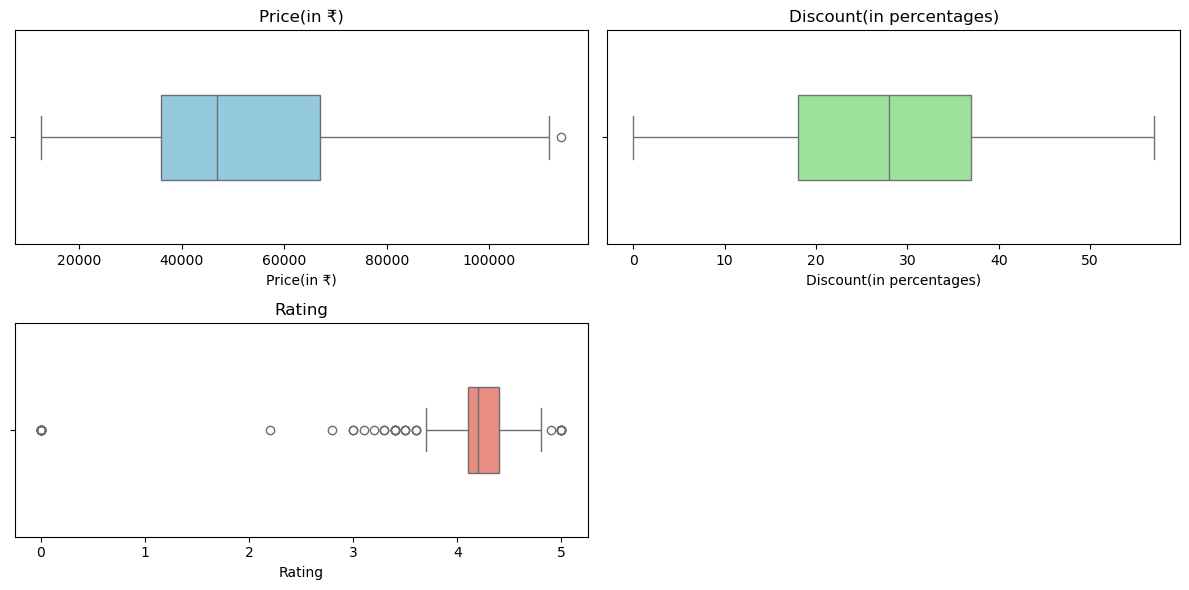

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(12, 6))

# Create 2x2 subplot layout
plt.subplot(2, 2, 1)
sns.boxplot(x=df["Price(in ₹)"], width=0.4, color='skyblue')
plt.title("Price(in ₹)")

plt.subplot(2, 2, 2)
sns.boxplot(x=df["Discount(in percentages)"], width=0.4, color='lightgreen')
plt.title("Discount(in percentages)")

plt.subplot(2, 2, 3)
sns.boxplot(x=df["Rating"], width=0.4, color='salmon')
plt.title("Rating")



plt.tight_layout()
plt.show()
